# 🎤 Speaker 1: Career and Compensation Analysis
**Focus:** Salary trends across time, experience levels, and job types.

In [58]:
#  Load libraries and dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

file_path = 'datajobs2.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df.head()

#  Filter for key job roles
target_roles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_filtered = df[df['job_title'].isin(target_roles)].copy()
df_filtered.reset_index(drop=True, inplace=True)
df_filtered.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
1,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
2,2024,EN,FT,Data Analyst,101520,USD,101520,US,0,US,M
3,2024,EN,FT,Data Analyst,45864,USD,45864,US,0,US,M
4,2024,SE,FT,Data Engineer,172469,USD,172469,US,0,US,M


1. Pay Progression


In [3]:
# Step 1: Pay Progression
pay_progression = df_filtered.groupby(['work_year', 'job_title'])['salary_in_usd'].mean().round(0).astype(int).reset_index()
pay_progression.sort_values(by=['job_title', 'work_year'])

,work_year,job_title,salary_in_usd
0,2020,Data Analyst,60911
3,2021,Data Analyst,78258
6,2022,Data Analyst,105140
9,2023,Data Analyst,108714
12,2024,Data Analyst,109426
1,2020,Data Engineer,85301
4,2021,Data Engineer,93258
7,2022,Data Engineer,138288
10,2023,Data Engineer,148983
13,2024,Data Engineer,146537


In [4]:
# For Data Analyst
pay_progression_DA = (
    df_filtered[df_filtered['job_title'] == 'Data Analyst']
    .groupby(['work_year', 'job_title'])['salary_in_usd']
    .mean()
    .round(0)
    .astype(int)
    .reset_index()
    .sort_values(by=['work_year'])
)
pay_progression_DA

,work_year,job_title,salary_in_usd
0,2020,Data Analyst,60911
1,2021,Data Analyst,78258
2,2022,Data Analyst,105140
3,2023,Data Analyst,108714
4,2024,Data Analyst,109426


In [5]:
# For Data Engineers
pay_progression_DE = (
    df_filtered[df_filtered['job_title'] == 'Data Engineer']
    .groupby(['work_year', 'job_title'])['salary_in_usd']
    .mean()
    .round(0)
    .astype(int)
    .reset_index()
    .sort_values(by=['work_year'])
)
pay_progression_DE

,work_year,job_title,salary_in_usd
0,2020,Data Engineer,85301
1,2021,Data Engineer,93258
2,2022,Data Engineer,138288
3,2023,Data Engineer,148983
4,2024,Data Engineer,146537


In [6]:
# For Data Scientist
pay_progression_DS = (
    df_filtered[df_filtered['job_title'] == 'Data Scientist']
    .groupby(['work_year', 'job_title'])['salary_in_usd']
    .mean()
    .round(0)
    .astype(int)
    .reset_index()
    .sort_values(by=['work_year'])
)
pay_progression_DS 


#Ask ChatGPT ooo

,work_year,job_title,salary_in_usd
0,2020,Data Scientist,85971
1,2021,Data Scientist,79366
2,2022,Data Scientist,130981
3,2023,Data Scientist,159635
4,2024,Data Scientist,151839


In [7]:
# Step 1: Filter for the desired jobs
selected_jobs = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_selected = df_filtered[df_filtered['job_title'].isin(selected_jobs)]

# Step 2: Group and get mean salary (existing logic)
pay_progression = (
    df_selected.groupby(['work_year', 'job_title'])['salary_in_usd']
    .mean()
    .round(0)
    .astype(int)
    .reset_index()
    .sort_values(by=['job_title', 'work_year'])
)

# Step 3: Count and percentage by job title
Dounts = (
    df_selected['job_title']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'job_title', 'job_title': 'count'})
)

# Ensure counts are integers
Dounts = (
    df_selected['job_title']
    .value_counts()
    .reset_index()
)
Dounts.columns = ['job_title', 'count']  # Ensure correct naming
Dounts['count'] = Dounts['count'].astype(int)  # Now safe to convert


# Step 4: Add percentage column
total_count = Dounts['count'].sum()
Dounts['percentage'] = (Dounts['count'] / total_count * 100).round(2)

pay_progression
Dounts


,job_title,count,percentage
0,Data Engineer,1842,36.40
1,Data Scientist,1835,36.26
2,Data Analyst,1384,27.35


2. Salary Disparities

In [8]:
# Step 2: Salary Disparities by Region & Experience Level
salary_by_region_exp = df_filtered.groupby(['job_title','work_year','experience_level','employee_residence'])['salary_in_usd'].mean().round(0).astype(int).reset_index()
#Calculate the Margin
salary_by_region_exp = salary_by_region_exp.sort_values(['job_title','work_year'])
salary_by_region_exp["salary_margin_pct"]= df_filtered.groupby('job_title')['salary_in_usd'].pct_change() * 100
salary_by_region_exp

,job_title,work_year,experience_level,employee_residence,salary_in_usd,salary_margin_pct
0,Data Analyst,2020,EN,DE,47899,NaN
1,Data Analyst,2020,EN,PT,22809,-26.436782
2,Data Analyst,2020,EN,US,81500,NaN
3,Data Analyst,2020,mid,FR,46759,-54.822695
4,Data Analyst,2020,mid,US,85000,79.655208
...,...,...,...,...,...,...
325,Data Scientist,2024,mid,EG,136100,-10.000000
326,Data Scientist,2024,mid,GB,105545,46.953405
327,Data Scientist,2024,mid,LV,62966,89.655172
328,Data Scientist,2024,mid,US,138484,-18.181818


In [9]:
# Step 2: Salary Disparities by Region & Experience Level
salary_by_region_exp = df_filtered.groupby(['job_title','work_year','employee_residence'])['salary_in_usd'].mean().round(0).astype(int).reset_index()
#Calculate the Margin
salary_by_region_exp = salary_by_region_exp.sort_values(['job_title','work_year'])
salary_by_region_exp["salary_margin_pct"]= df_filtered.groupby('job_title')['salary_in_usd'].pct_change() * 100
salary_by_region_exp

,job_title,work_year,employee_residence,salary_in_usd,salary_margin_pct
0,Data Analyst,2020,DE,47899,NaN
1,Data Analyst,2020,FR,46759,-26.436782
2,Data Analyst,2020,PT,22809,NaN
3,Data Analyst,2020,US,82667,-54.822695
4,Data Analyst,2021,AU,42028,79.655208
...,...,...,...,...,...
207,Data Scientist,2024,LV,62966,-29.175807
208,Data Scientist,2024,NZ,144000,96.725664
209,Data Scientist,2024,PT,72222,-46.153846
210,Data Scientist,2024,US,159353,1.503759


In [10]:
#  Salary Progression for Data Analyst rows
sal_DA = salary_by_region_exp[salary_by_region_exp['job_title'] == "Data Analyst"].copy()

#  Group by year and sum salaries
fix_Da = (
    sal_DA.groupby("work_year", as_index=False)
         .agg({"salary_in_usd": "sum"})
         .sort_values("work_year")  # important for pct_change to be correct
)

#  Calculate year-to-year margin %
fix_Da["salary_margin_pct"] = fix_Da["salary_in_usd"].pct_change() * 100

# Round numbers
fix_Da["salary_margin_pct"] = fix_Da["salary_margin_pct"].round(2)
fix_Da["salary_in_usd"] = fix_Da["salary_in_usd"].round(2)

#  Format percentage as string for display
fix_Da["salary_margin_pct"] = fix_Da["salary_margin_pct"].astype(str) + "%"

fix_Da


,work_year,salary_in_usd,salary_margin_pct
0,2020,200134,nan%
1,2021,529337,164.49%
2,2022,665227,25.67%
3,2023,1232261,85.24%
4,2024,1309723,6.29%


##### The Visualization

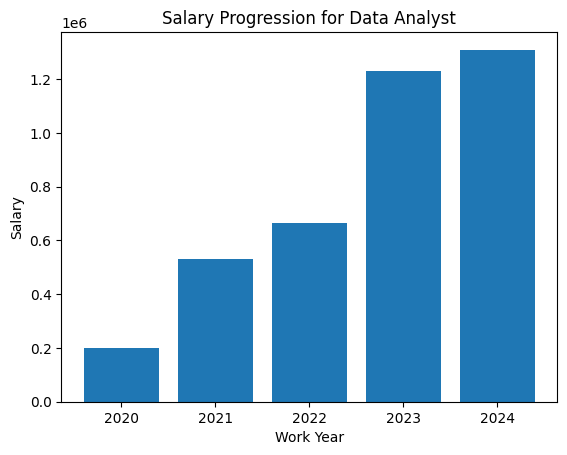

In [ ]:

salary_DA = fix_Da.salary_in_usd
work_DA = fix_Da.work_year

plt.bar(work_DA, salary_DA)
plt.title('Salary Disparities for Data Analyst')
plt.ylabel('Salary')
plt.xlabel('Work Year')
plt.show()

In [12]:
#  Salary Progression for Data Engineer rows
sal_DE = salary_by_region_exp[salary_by_region_exp['job_title'] == "Data Engineer"].copy()

#  Group by year and sum salaries
fix_DE = (
    sal_DE.groupby("work_year", as_index=False)
         .agg({"salary_in_usd": "sum"})
         .sort_values("work_year")  # important for pct_change to be correct
)

#  Calculate year-to-year margin %
fix_DE["salary_margin_pct"] = fix_DE["salary_in_usd"].pct_change() * 100

# Round numbers
fix_DE["salary_margin_pct"] = fix_DE["salary_margin_pct"].round(2)
fix_DE["salary_in_usd"] = fix_DE["salary_in_usd"].round(2)

#  Format percentage as string for display
fix_DE["salary_margin_pct"] = fix_DE["salary_margin_pct"].astype(str) + "%"

fix_DE


,work_year,salary_in_usd,salary_margin_pct
0,2020,734268,nan%
1,2021,659409,-10.2%
2,2022,1183733,79.51%
3,2023,1513087,27.82%
4,2024,1303820,-13.83%


##### The Visualization

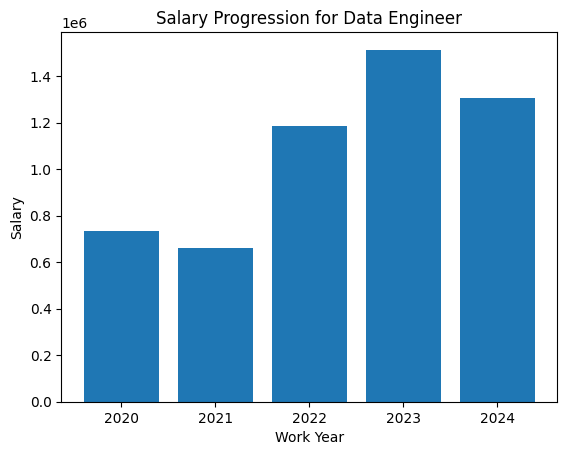

In [13]:
salary_DE = fix_DE.salary_in_usd
work_DE = fix_DE.work_year

plt.bar(work_DE, salary_DE)
plt.title('Salary Progression for Data Engineer')
plt.ylabel('Salary')
plt.xlabel('Work Year')
plt.show()

In [14]:
#  Salary Progression for Data Scientist rows
sal_DS = salary_by_region_exp[salary_by_region_exp['job_title'] == "Data Scientist"].copy()

#  Group by year and sum salaries
fix_DS = (
    sal_DS.groupby("work_year", as_index=False)
         .agg({"salary_in_usd": "sum"})
         .sort_values("work_year")  # important for pct_change to be correct
)

#  Calculate year-to-year margin %
fix_DS["salary_margin_pct"] = fix_DS["salary_in_usd"].pct_change() * 100

# Round numbers
fix_DS["salary_margin_pct"] = fix_DS["salary_margin_pct"].round(2)
fix_DS["salary_in_usd"] = fix_DS["salary_in_usd"].round(2)

#  Format percentage as string for display
fix_DS["salary_margin_pct"] = fix_DS["salary_margin_pct"].astype(str) + "%"

fix_DS


,work_year,salary_in_usd,salary_margin_pct
0,2020,698418,nan%
1,2021,752904,7.8%
2,2022,1359958,80.63%
3,2023,1877278,38.04%
4,2024,1621011,-13.65%


##### The Visualization

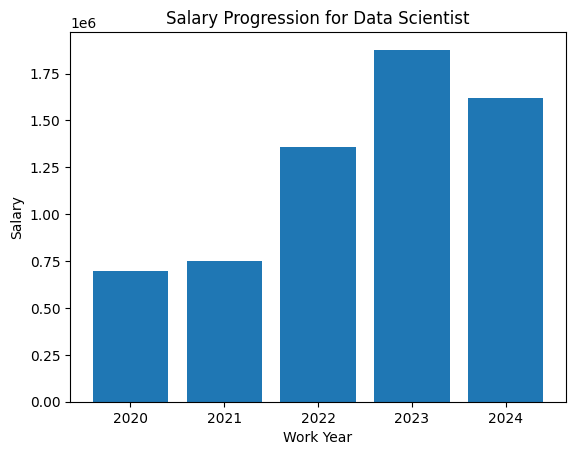

In [15]:
salary_DS = fix_DS.salary_in_usd
work_DS = fix_DS.work_year

plt.bar(work_DS, salary_DS)
plt.title('Salary Progression for Data Scientist')
plt.ylabel('Salary')
plt.xlabel('Work Year')
plt.show()

3. Employment Type Pay Gap

In [16]:
# Step 3: Employment Type Pay Gap
employment_salary = df_filtered.groupby(['job_title', 'employment_type'])['salary_in_usd'].mean().round(0).astype(int).reset_index()
employment_salary

,job_title,employment_type,salary_in_usd
0,Data Analyst,CT,90000
1,Data Analyst,FT,108151
2,Data Analyst,PT,56917
3,Data Engineer,FL,20000
4,Data Engineer,FT,145221
5,Data Engineer,PT,65168
6,Data Scientist,CT,137974
7,Data Scientist,FL,100000
8,Data Scientist,FT,150468
9,Data Scientist,PT,117658


##### Visualization

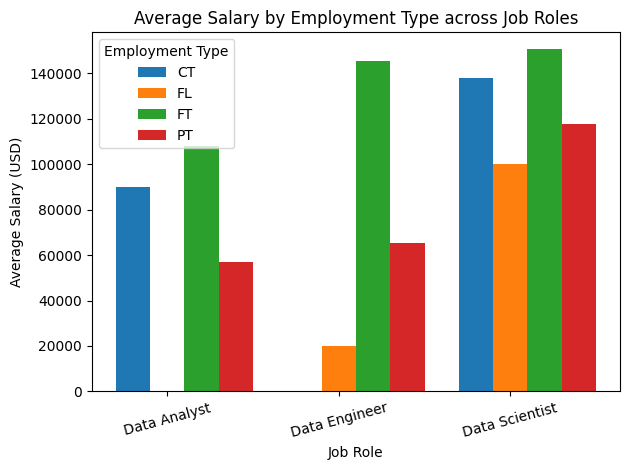

In [46]:
employment_salary = (
    df_filtered.groupby(['job_title', 'employment_type'])['salary_in_usd']
    .mean()
    .round(0)
    .astype(int)
    .reset_index()
)


selected_roles = ["Data Analyst", "Data Scientist", "Data Engineer"]

employment_salary_filtered = employment_salary[
    employment_salary['job_title'].isin(selected_roles)
]


# Pivot for easier plotting
pivot_table = employment_salary_filtered.pivot(
    index='job_title', columns='employment_type', values='salary_in_usd'
).fillna(0)

x = np.arange(len(pivot_table.index))  # job roles
bar_width = 0.2



for i, emp_type in enumerate(pivot_table.columns):
    plt.bar(x + i*bar_width, pivot_table[emp_type], width=bar_width, label=emp_type)

plt.xticks(x + bar_width, pivot_table.index, rotation=15)
plt.xlabel("Job Role")
plt.ylabel("Average Salary (USD)")
plt.title("Average Salary by Employment Type across Job Roles")
plt.legend(title="Employment Type")
plt.tight_layout()
plt.show()


# 🎤 Speaker 2: Geographic and Organizational Impact
**Focus:** Country-based salary trends, remote work impact, and company size effects.

1. Location Based Trend

In [49]:
# Step 1: Location-Based Pay Trends
selected_countries = ['US', 'GB', 'DK', 'ES', 'FR', 'CA', 'IN', 'AU']
df_country = df_filtered[df_filtered['company_location'].isin(selected_countries)]
country_salary = df_country.groupby([ 'job_title','work_year','company_location'])['salary_in_usd'].mean().round(0).astype(int).reset_index()
job_counts = df_country['company_location'].value_counts().reset_index()
job_counts.columns = ['company_location', 'job_postings']
country_summary = pd.merge(country_salary, job_counts, on='company_location')
country_summary

,job_title,work_year,company_location,salary_in_usd,job_postings
0,Data Analyst,2020,FR,46759,37
1,Data Analyst,2020,US,82667,4183
2,Data Analyst,2021,AU,42028,25
3,Data Analyst,2021,CA,71786,201
4,Data Analyst,2021,FR,59102,37
...,...,...,...,...,...
78,Data Scientist,2024,ES,54444,48
79,Data Scientist,2024,FR,129458,37
80,Data Scientist,2024,GB,77687,305
81,Data Scientist,2024,IN,48019,24


In [51]:
#Location Pay Trend For Data Analyst
selected_countries = ['US', 'GB', 'DK', 'ES', 'FR', 'CA', 'IN', 'AU']

df_country = df_filtered[ (df_filtered['company_location'].isin(selected_countries)) & (df_filtered['job_title'] == "Data Analyst")]

country_salary = (df_country.groupby(['job_title', 'work_year', 'company_location'])['salary_in_usd'].mean().round(0).astype(int).reset_index())

job_counts = ( df_country['company_location'] .value_counts() .reset_index())
job_counts.columns = ['company_location', 'job_postings']
country_summary_DA = pd.merge(country_salary, job_counts, on='company_location')
country_summary_DA


,job_title,work_year,company_location,salary_in_usd,job_postings
0,Data Analyst,2020,FR,46759,6
1,Data Analyst,2020,US,82667,1163
2,Data Analyst,2021,AU,42028,10
3,Data Analyst,2021,CA,71786,44
4,Data Analyst,2021,FR,59102,6
5,Data Analyst,2021,GB,51519,92
6,Data Analyst,2021,IN,16904,5
7,Data Analyst,2021,US,93077,1163
8,Data Analyst,2022,AU,171000,10
9,Data Analyst,2022,CA,79412,44


##### The Visualization

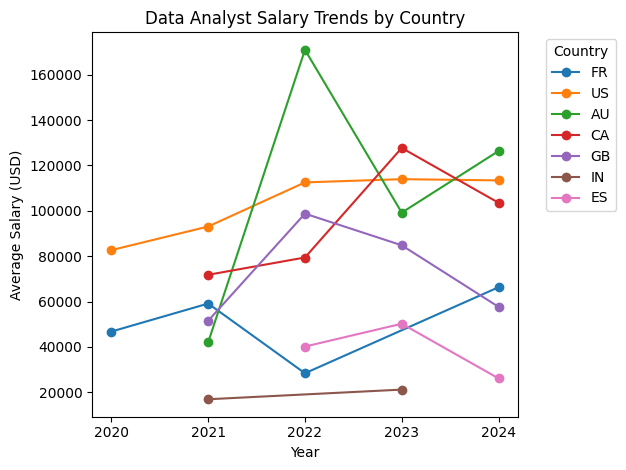

In [63]:
#Line Plot

for country in country_summary_DA['company_location'].unique():
    subset = country_summary_DA[country_summary_DA['company_location'] == country]
    plt.plot(subset['work_year'], subset['salary_in_usd'], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.title("Data Analyst Salary Trends by Country")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


In [53]:
#Location Pay Trend For Data Engineer
selected_countries = ['US', 'GB', 'DK', 'ES', 'FR', 'CA', 'IN', 'AU']

df_engineer = df_filtered[ (df_filtered['company_location'].isin(selected_countries)) & (df_filtered['job_title'] == "Data Engineer")]

country_salary = (df_engineer.groupby(['job_title', 'work_year', 'company_location'])['salary_in_usd'].mean().round(0).astype(int).reset_index())

job_counts = ( df_engineer['company_location'] .value_counts() .reset_index())
job_counts.columns = ['company_location', 'job_postings']
country_summary_DE = pd.merge(country_salary, job_counts, on='company_location')
country_summary_DE


,job_title,work_year,company_location,salary_in_usd,job_postings
0,Data Engineer,2020,ES,79833,19
1,Data Engineer,2020,FR,70139,9
2,Data Engineer,2020,GB,112872,124
3,Data Engineer,2020,US,133700,1523
4,Data Engineer,2021,AU,75050,5
5,Data Engineer,2021,GB,78963,124
6,Data Engineer,2021,IN,26032,7
7,Data Engineer,2021,US,120622,1523
8,Data Engineer,2022,CA,158300,66
9,Data Engineer,2022,ES,61070,19


##### Visualization

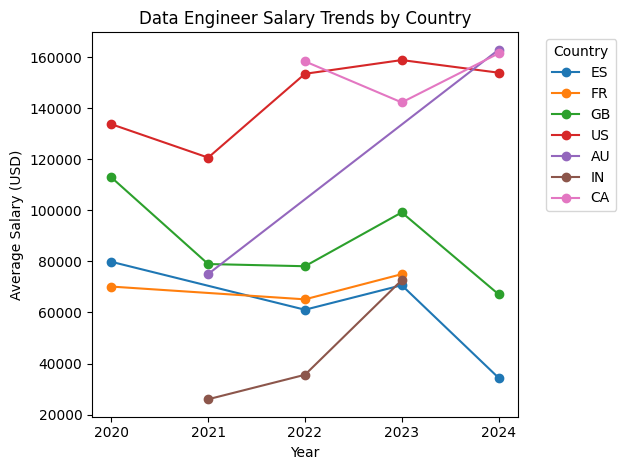

In [ ]:


#Line Plot

for country in country_summary_DE['company_location'].unique():
    subset = country_summary_DE[country_summary_DE['company_location'] == country]
    plt.plot(subset['work_year'], subset['salary_in_usd'], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.title("Data Engineer Salary Trends by Country")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()



In [64]:
#Location Pay Trend For Data Scientist
selected_countries = ['US', 'GB', 'DK', 'ES', 'FR', 'CA', 'IN', 'AU']

df_scientist = df_filtered[ (df_filtered['company_location'].isin(selected_countries)) & (df_filtered['job_title'] == "Data Scientist")]

country_salary = (df_scientist.groupby(['job_title', 'work_year', 'company_location'])['salary_in_usd'].mean().round(0).astype(int).reset_index())

job_counts = ( df_scientist['company_location'] .value_counts() .reset_index())
job_counts.columns = ['company_location', 'job_postings']
country_summary_DS = pd.merge(country_salary, job_counts, on='company_location')
country_summary_DS

,job_title,work_year,company_location,salary_in_usd,job_postings
0,Data Scientist,2020,ES,38776,18
1,Data Scientist,2020,FR,44478,22
2,Data Scientist,2020,GB,76958,89
3,Data Scientist,2020,IN,40481,12
4,Data Scientist,2020,US,139067,1497
5,Data Scientist,2021,CA,89068,91
6,Data Scientist,2021,ES,42317,18
7,Data Scientist,2021,FR,54291,22
8,Data Scientist,2021,GB,86585,89
9,Data Scientist,2021,IN,32591,12


##### The Visualization

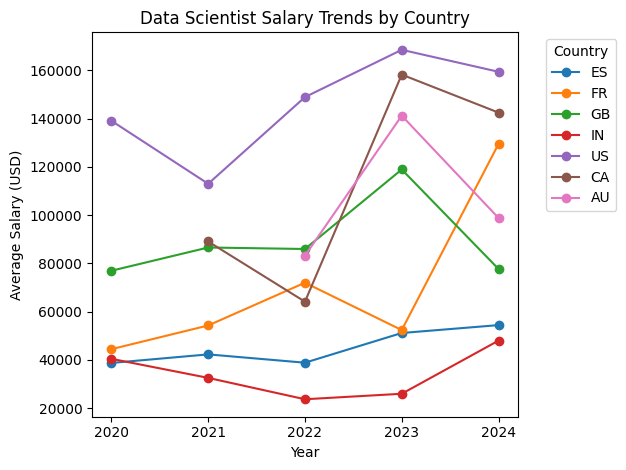

In [65]:
#Line Plot

for country in country_summary_DS['company_location'].unique():
    subset = country_summary_DS[country_summary_DS['company_location'] == country]
    plt.plot(subset['work_year'], subset['salary_in_usd'], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.title("Data Scientist Salary Trends by Country")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


2. Remote Work Influence

In [32]:
# Step 2: Remote Work Influence
remote_labels = {0: 'On-Site', 50: 'Hybrid', 100: 'Remote'}
df_filtered['remote_label'] = df_filtered['remote_ratio'].map(remote_labels)

remote_counts = df_filtered['remote_label'].value_counts().reset_index()
remote_counts.columns = ['Remote Work Type', 'Job Count']
remote_counts

,Remote Work Type,Job Count
0,On-Site,3145
1,Remote,1822
2,Hybrid,94


In [33]:
# Salary by Remote Type
highest_remote_type = df_filtered.groupby('remote_label')['salary_in_usd'].mean().round(0).astype(int).reset_index()
highest_remote_type.columns = ['Remote Work Type', 'Average Salary (USD)']
highest_remote_type

,Remote Work Type,Average Salary (USD)
0,Hybrid,67964
1,On-Site,139268
2,Remote,135932


##### Visualization

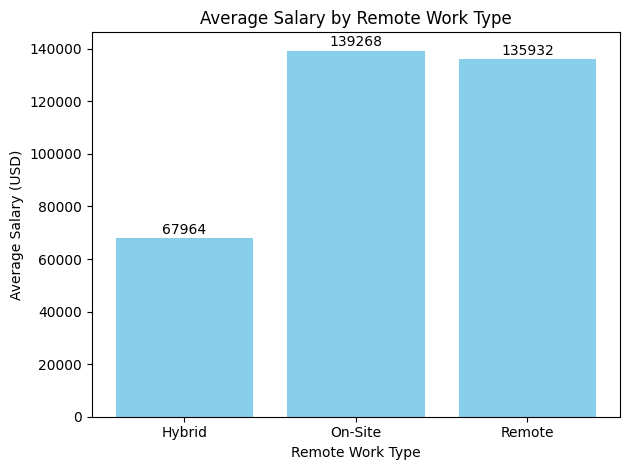

In [67]:

plt.bar(highest_remote_type['Remote Work Type'],
        highest_remote_type['Average Salary (USD)'],
        color="skyblue")

plt.xlabel("Remote Work Type")
plt.ylabel("Average Salary (USD)")
plt.title("Average Salary by Remote Work Type")

# Add labels on top of bars
for i, val in enumerate(highest_remote_type['Average Salary (USD)']):
    plt.text(i, val + 500, str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [34]:
# Regional dominance of remote jobs
remote_jobs = df_filtered[df_filtered['remote_label'] == 'Remote']
remote_job_regions = remote_jobs['employee_residence'].value_counts().reset_index()
remote_job_regions.columns = ['Country', 'Remote Job Count']
remote_job_regions = remote_job_regions.head(10)
remote_job_regions



,Country,Remote Job Count
0,US,1517
1,GB,83
2,CA,75
3,ES,25
4,FR,13
5,IN,13
6,DE,11
7,GR,10
8,PL,9
9,AR,8


3. Company Size Effect

In [35]:
# Step 3: Company Size Effects
company_salary = df_filtered.groupby(['company_size', 'job_title',])['salary_in_usd'].mean().round(0).astype(int).reset_index()
company_salary

,company_size,job_title,salary_in_usd
0,L,Data Analyst,82840
1,L,Data Engineer,112558
2,L,Data Scientist,110609
3,M,Data Analyst,109335
4,M,Data Engineer,147066
5,M,Data Scientist,154341
6,S,Data Analyst,67913
7,S,Data Engineer,61114
8,S,Data Scientist,76050


##### Visualization

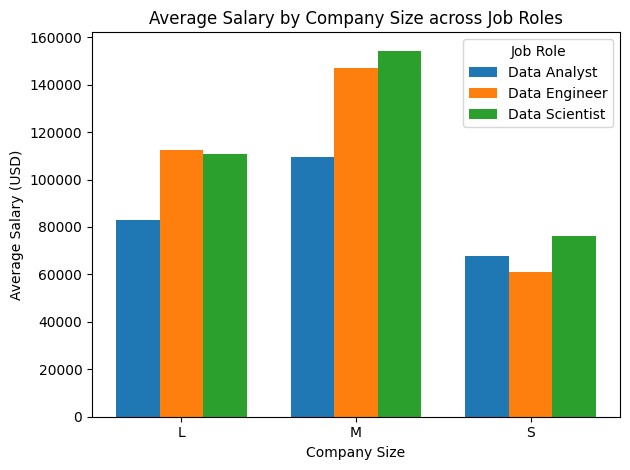

In [69]:
pivot_table = company_salary.pivot(index='company_size',
                                   columns='job_title',
                                   values='salary_in_usd').fillna(0)



x = np.arange(len(pivot_table.index))  # company sizes
bar_width = 0.25



for i, job in enumerate(pivot_table.columns):
    plt.bar(x + i*bar_width, pivot_table[job], width=bar_width, label=job)

plt.xticks(x + bar_width, pivot_table.index)
plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD)")
plt.title("Average Salary by Company Size across Job Roles")
plt.legend(title="Job Role")
plt.tight_layout()
plt.show()


# 🎤 Speaker 3: Workforce Planning – Hiring Bias
**Focus:** Bias in hiring levels by company and region

1. Experience Level Hiring Bias

In [23]:
# Step 1: Hiring Bias by Company Size
hiring_bias_company = df_filtered.groupby(['job_title', 'experience_level', 'company_size']).size().reset_index(name='count')
hiring_bias_company.sort_values(by='count', ascending=False).head(15)

,job_title,experience_level,company_size,count
27,Data Scientist,SE,M,1086
16,Data Engineer,SE,M,1059
5,Data Analyst,SE,M,638
19,Data Engineer,mid,M,509
30,Data Scientist,mid,M,473
8,Data Analyst,mid,M,338
1,Data Analyst,EN,M,322
14,Data Engineer,EX,M,109
22,Data Scientist,EN,M,103
11,Data Engineer,EN,M,67


In [24]:
#For Data Analyst
df_analyst = df_filtered[df_filtered['job_title'] == 'Data Analyst']

# Group by experience level and company size
hiring_bias_company_DA = (
    df_analyst.groupby(['experience_level', 'company_size'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)
hiring_bias_company_DA

,experience_level,company_size,count
5,SE,M,638
8,mid,M,338
1,EN,M,322
3,EX,M,22
0,EN,L,19
7,mid,L,16
4,SE,L,11
6,SE,S,9
2,EN,S,7
9,mid,S,2


##### The Visualization

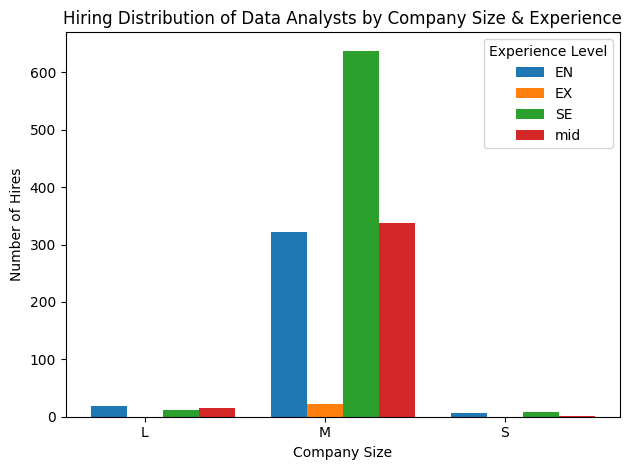

In [25]:


# Unique categories
company_sizes = hiring_bias_company_DA['company_size'].unique()
experience_levels = hiring_bias_company_DA['experience_level'].unique()

# Pivot the data for plotting
pivot_table = hiring_bias_company_DA.pivot(index='company_size', 
                                        columns='experience_level', 
                                        values='count').fillna(0)

# Bar width setup
x = np.arange(len(pivot_table.index))  # company sizes on x-axis
bar_width = 0.2

# Plot grouped bars
# plt.figure(figsize=(10,6))
for i, exp in enumerate(pivot_table.columns):
    plt.bar(x + i*bar_width, pivot_table[exp], width=bar_width, label=exp)

plt.xticks(x + bar_width, pivot_table.index)
plt.xlabel("Company Size")
plt.ylabel("Number of Hires")
plt.title("Hiring Distribution of Data Analysts by Company Size & Experience")
plt.legend(title="Experience Level")
plt.tight_layout()
plt.show()


In [26]:
#For Data Engineer
df_analyst = df_filtered[df_filtered['job_title'] == 'Data Engineer']

# Group by experience level and company size
hiring_bias_company_DE = (
    df_analyst.groupby(['experience_level', 'company_size'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)
hiring_bias_company_DE

,experience_level,company_size,count
6,SE,M,1059
9,mid,M,509
4,EX,M,109
1,EN,M,67
5,SE,L,37
8,mid,L,35
0,EN,L,16
10,mid,S,4
7,SE,S,3
2,EN,S,2


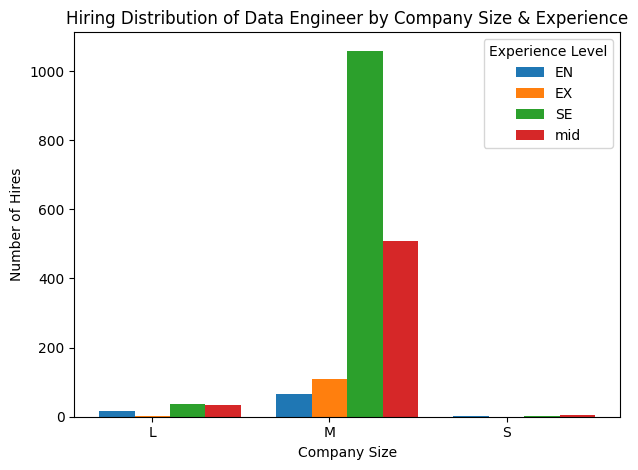

In [27]:


# Unique categories
company_sizes = hiring_bias_company_DE['company_size'].unique()
experience_levels = hiring_bias_company_DE['experience_level'].unique()

# Pivot the data for plotting
pivot_table = hiring_bias_company_DE.pivot(index='company_size', 
                                        columns='experience_level', 
                                        values='count').fillna(0)

# Bar width setup
x = np.arange(len(pivot_table.index))  # company sizes on x-axis
bar_width = 0.2

# Plot grouped bars
# plt.figure(figsize=(10,6))
for i, exp in enumerate(pivot_table.columns):
    plt.bar(x + i*bar_width, pivot_table[exp], width=bar_width, label=exp)

plt.xticks(x + bar_width, pivot_table.index)
plt.xlabel("Company Size")
plt.ylabel("Number of Hires")
plt.title("Hiring Distribution of Data Engineer by Company Size & Experience")
plt.legend(title="Experience Level")
plt.tight_layout()
plt.show()


In [ ]:
#For Data Scientist
df_analyst = df_filtered[df_filtered['job_title'] == 'Data Scientist']

# Group by experience level and company size
hiring_bias_company_DS = (
    df_analyst.groupby(['experience_level', 'company_size'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)
hiring_bias_company_DS

,experience_level,company_size,count
6,SE,M,1086
9,mid,M,473
1,EN,M,103
5,SE,L,49
8,mid,L,45
3,EX,M,26
0,EN,L,20
10,mid,S,16
2,EN,S,9
7,SE,S,7


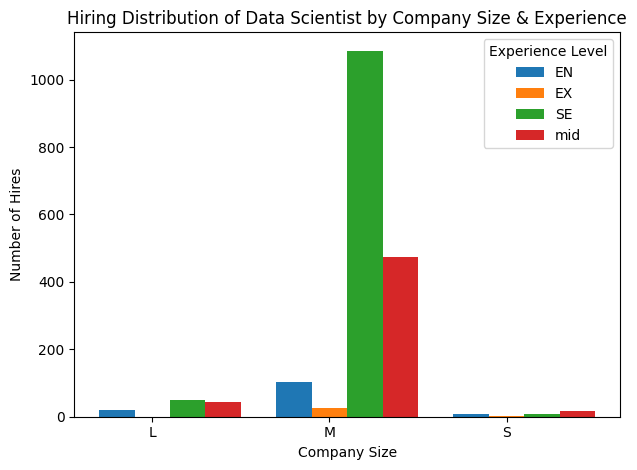

In [29]:


# Unique categories
company_sizes = hiring_bias_company_DS['company_size'].unique()
experience_levels = hiring_bias_company_DS['experience_level'].unique()

# Pivot the data for plotting
pivot_table = hiring_bias_company_DS.pivot(index='company_size', 
                                        columns='experience_level', 
                                        values='count').fillna(0)

# Bar width setup
x = np.arange(len(pivot_table.index))  # company sizes on x-axis
bar_width = 0.2

# Plot grouped bars
# plt.figure(figsize=(10,6))
for i, exp in enumerate(pivot_table.columns):
    plt.bar(x + i*bar_width, pivot_table[exp], width=bar_width, label=exp)

plt.xticks(x + bar_width, pivot_table.index)
plt.xlabel("Company Size")
plt.ylabel("Number of Hires")
plt.title("Hiring Distribution of Data Scientist by Company Size & Experience")
plt.legend(title="Experience Level")
plt.tight_layout()
plt.show()


2. Work Year Trend

In [30]:
# Step 2: Hiring Bias by Region
hiring_bias_region = df_filtered.groupby(['job_title', 'experience_level', 'employee_residence']).size().reset_index(name='count')
hiring_bias_region.sort_values(by='count', ascending=False).head(15)

,job_title,experience_level,employee_residence,count
163,Data Scientist,SE,US,994
91,Data Engineer,SE,US,962
38,Data Analyst,SE,US,571
116,Data Engineer,mid,US,400
194,Data Scientist,mid,US,386
55,Data Analyst,mid,US,288
20,Data Analyst,EN,US,278
69,Data Engineer,EX,US,101
137,Data Scientist,EN,US,86
145,Data Scientist,SE,CA,66


In [37]:
# Step 1: Remote jobs trend
yearly_jobs = df_filtered['work_year'].value_counts().sort_index().reset_index()
yearly_jobs.columns = ['Year', 'Total Jobs']
remote_year = df_filtered[df_filtered['remote_label'] == 'Remote']
remote_per_year = remote_year['work_year'].value_counts().sort_index().reset_index()
remote_per_year.columns = ['Year', 'Remote Jobs']
remote_trend = pd.merge(yearly_jobs, remote_per_year, on='Year', how='left').fillna(0)
remote_trend['Remote %'] = ((remote_trend['Remote Jobs'] / remote_trend['Total Jobs']) * 100) .round(0)
remote_trend

,Year,Total Jobs,Remote Jobs,Remote %
0,2020,40,20,50.0
1,2021,95,53,56.0
2,2022,696,364,52.0
3,2023,2341,904,39.0
4,2024,1889,481,25.0


##### Visualization

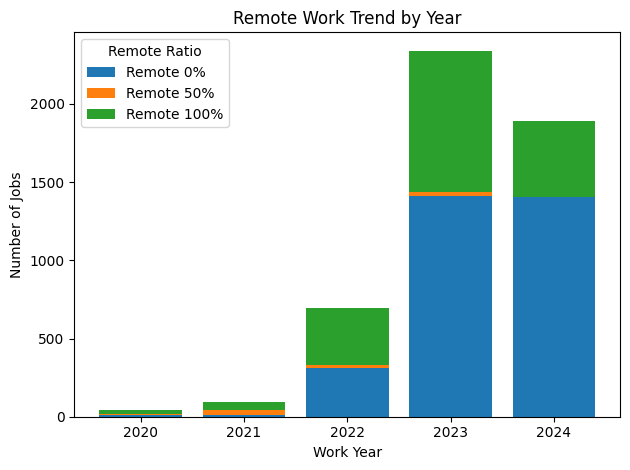

In [38]:
hiring_remote_trend = (
    df_filtered.groupby(['work_year', 'remote_ratio'])
    .size()
    .reset_index(name='count')
    .sort_values(by=['work_year', 'remote_ratio'])
)


# import matplotlib.pyplot as plt

# Pivot table for stacked bar
pivot_table = hiring_remote_trend.pivot(index='work_year', 
                                        columns='remote_ratio', 
                                        values='count').fillna(0)

# plt.figure(figsize=(10,6))

bottom_vals = None
for remote_val in pivot_table.columns:
    plt.bar(pivot_table.index, pivot_table[remote_val],
            bottom=bottom_vals, label=f"Remote {remote_val}%")
    # Update bottom for stacking
    bottom_vals = pivot_table[remote_val] if bottom_vals is None else bottom_vals + pivot_table[remote_val]

plt.xlabel("Work Year")
plt.ylabel("Number of Jobs")
plt.title("Remote Work Trend by Year")
plt.legend(title="Remote Ratio")
plt.tight_layout()
plt.show()


In [39]:
# Step 2: Contract roles trend
contract_jobs = df_filtered[df_filtered['employment_type'] == 'CT']
contract_per_year = contract_jobs['work_year'].value_counts().sort_index().reset_index()
contract_per_year.columns = ['Year', 'Contract Jobs']
contract_trend = pd.merge(yearly_jobs, contract_per_year, on='Year', how='left').fillna(0)
contract_trend['Contract %'] = ((contract_trend['Contract Jobs'] / contract_trend['Total Jobs']) * 100).round(3)
contract_trend

,Year,Total Jobs,Contract Jobs,Contract %
0,2020,40,0.0,0.000
1,2021,95,0.0,0.000
2,2022,696,1.0,0.144
3,2023,2341,0.0,0.000
4,2024,1889,4.0,0.212


##### Visualization

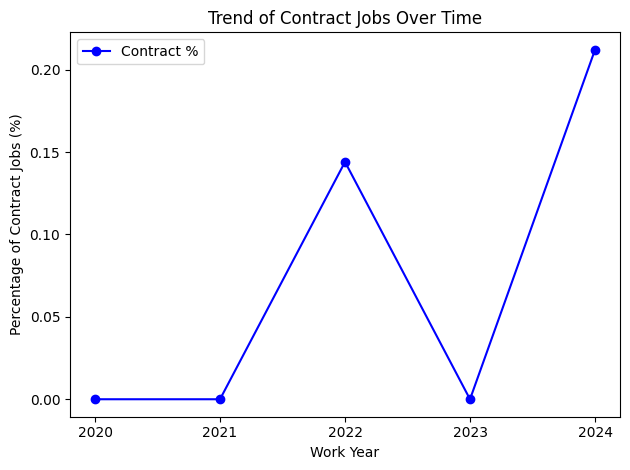

In [60]:


plt.plot(contract_trend['Year'], contract_trend['Contract %'], marker="o", color="blue", label="Contract %")

plt.xlabel("Work Year")
plt.ylabel("Percentage of Contract Jobs (%)")
plt.title("Trend of Contract Jobs Over Time")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()
